# 📊 EDA — Exploratory Data Analysis
> **Notebook 2 of 4** — Run after `01_data_generation.ipynb`.
> Explores inventory aging, revenue distribution, seasonality, and customer behaviour.
> Outputs: `../figures/*.png`

## 0 · Imports & Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3, os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_DIR    = "../data/generated_data"
SQL_DIR     = "../data/sql"
FIGURES_DIR = "../figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Load CSVs
categories  = pd.read_csv(f"{DATA_DIR}/categories.csv")
products    = pd.read_csv(f"{DATA_DIR}/products.csv")
customers   = pd.read_csv(f"{DATA_DIR}/customers.csv")
rentals     = pd.read_csv(f"{DATA_DIR}/rentals.csv", parse_dates=["rental_start_date", "rental_end_date", "actual_return_date", "expected_return_date"])
returns     = pd.read_csv(f"{DATA_DIR}/return_conditions.csv")
events      = pd.read_csv(f"{DATA_DIR}/inventory_events.csv")
comparison  = pd.read_csv(f"{DATA_DIR}/rental_revenue_vs_discount.csv")

print(f"Products:  {len(products):,}")
print(f"Customers: {len(customers):,}")
print(f"Rentals:   {len(rentals):,}")
print(f"Date range: {rentals['rental_start_date'].min().date()} → {rentals['rental_start_date'].max().date()}")


Products:  690
Customers: 2,000
Rentals:   1,264
Date range: 2020-11-22 → 2024-12-30


## 1 · Revenue Distribution by Category

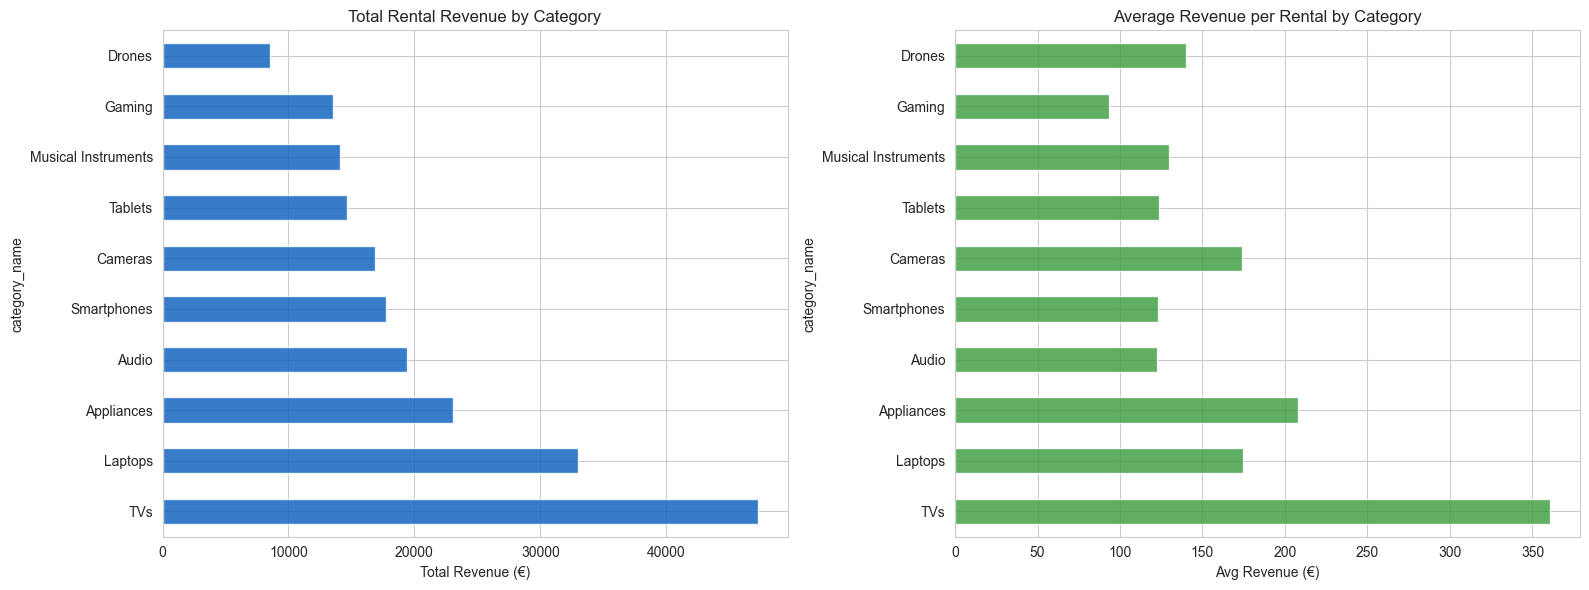

In [3]:
# Which categories generate the most rental revenue?
rental_detail = rentals.merge(products[["product_id", "category_id", "original_retail_price"]], on="product_id")
rental_detail = rental_detail.merge(categories[["category_id", "category_name"]], on="category_id")

rev_by_cat = rental_detail.groupby("category_name")["total_rental_revenue"].agg(["sum", "mean", "count"])
rev_by_cat.columns = ["total_revenue", "avg_revenue", "rental_count"]
rev_by_cat = rev_by_cat.sort_values("total_revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rev_by_cat["total_revenue"].plot(kind="barh", ax=axes[0], color="#1565C0", alpha=0.85)
axes[0].set_title("Total Rental Revenue by Category")
axes[0].set_xlabel("Total Revenue (€)")

rev_by_cat["avg_revenue"].plot(kind="barh", ax=axes[1], color="#43A047", alpha=0.85)
axes[1].set_title("Average Revenue per Rental by Category")
axes[1].set_xlabel("Avg Revenue (€)")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/revenue_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 2 · Rental Timeline — Seasonal Patterns

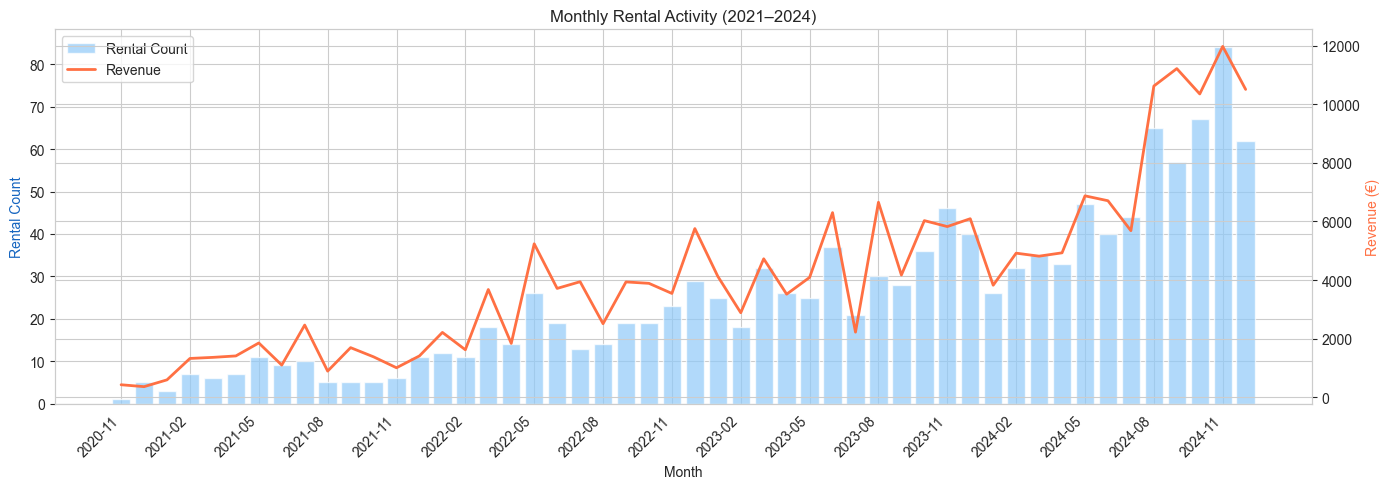

In [4]:
# How did rental activity and revenue evolve month by month?
rentals["rental_month"] = rentals["rental_start_date"].dt.to_period("M")
monthly = rentals.groupby("rental_month").agg(
    count=("rental_id", "count"),
    revenue=("total_rental_revenue", "sum")
).reset_index()
monthly["rental_month"] = monthly["rental_month"].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(range(len(monthly)), monthly["count"], color="#90CAF9", alpha=0.7, label="Rental Count")
ax1.set_ylabel("Rental Count", color="#1565C0")
ax1.set_xlabel("Month")

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly["revenue"], color="#FF7043", linewidth=2, label="Revenue")
ax2.set_ylabel("Revenue (€)", color="#FF7043")

# Show month labels on x-axis every 3 months so it doesn't crowd
tick_positions = range(0, len(monthly), 3)
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([monthly["rental_month"].iloc[i] for i in tick_positions], rotation=45, ha="right")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Monthly Rental Activity (2021–2024)")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/seasonal_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

## 3 · Customer Segmentation

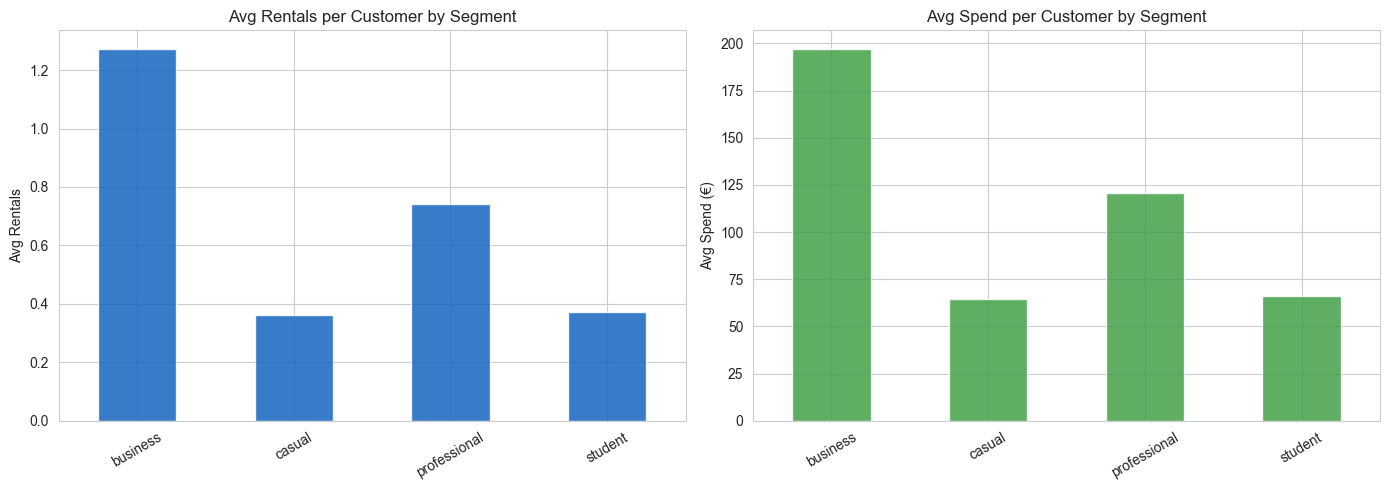

In [5]:
# How do rentals and spending break down by customer segment?
# We include never-rented customers (0 rentals) to show the full conversion picture
cust_rentals = rentals.groupby("customer_id").agg(
    total_rentals=("rental_id", "count"),
    total_spent=("total_rental_revenue", "sum"),
    avg_duration=("rental_duration_days", "mean")
).reset_index()

# Left join so customers who never rented still appear with 0
all_customers = customers[["customer_id", "customer_segment"]].merge(
    cust_rentals[["customer_id", "total_rentals", "total_spent"]], 
    on="customer_id", 
    how="left"
).fillna({"total_rentals": 0, "total_spent": 0})

seg_summary = all_customers.groupby("customer_segment").agg(
    avg_rentals=("total_rentals", "mean"),
    avg_spent=("total_spent", "mean"),
    customer_count=("customer_id", "count")
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_summary.plot(kind="bar", x="customer_segment", y="avg_rentals", ax=axes[0], color="#1565C0", alpha=0.85, legend=False)
axes[0].set_title("Avg Rentals per Customer by Segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Avg Rentals")
axes[0].tick_params(axis="x", rotation=30)

seg_summary.plot(kind="bar", x="customer_segment", y="avg_spent", ax=axes[1], color="#43A047", alpha=0.85, legend=False)
axes[1].set_title("Avg Spend per Customer by Segment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Spend (€)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/customer_segments.png", dpi=150, bbox_inches="tight")
plt.show()


## 4 · Inventory Aging — The Dead Zone

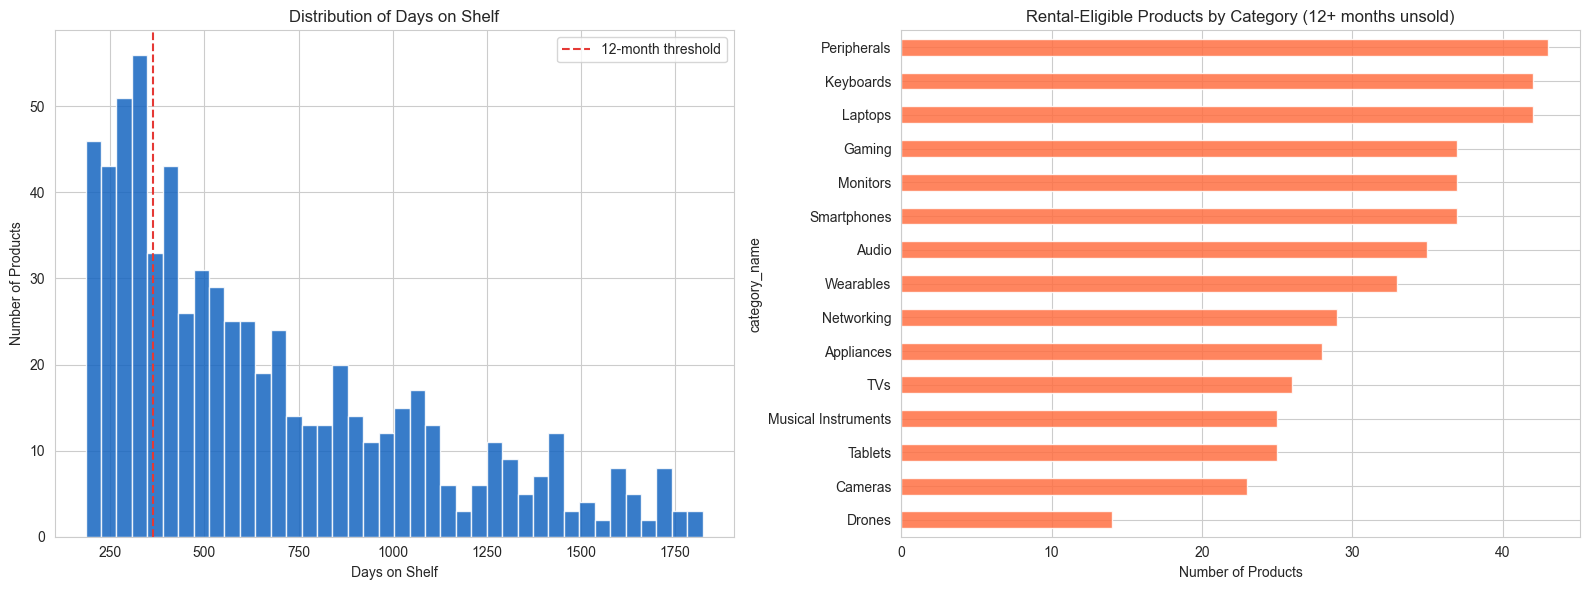

Total rental-eligible products: 476 out of 690 (69.0%)


In [6]:
# How long have products been sitting unsold?
# The 365-day mark is the threshold for rental eligibility — our "dead zone"
products_copy = products.copy()
products_copy["listed_date"] = pd.to_datetime(products_copy["listed_date"])
products_copy["days_on_shelf"] = (pd.Timestamp("2024-12-31") - products_copy["listed_date"]).dt.days
products_copy = products_copy.merge(categories[["category_id", "category_name"]], on="category_id")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: distribution of all products by days on shelf
axes[0].hist(products_copy["days_on_shelf"], bins=40, color="#1565C0", edgecolor="white", alpha=0.85)
axes[0].axvline(x=365, color="#E53935", linestyle="--", linewidth=1.5, label="12-month threshold")
axes[0].set_title("Distribution of Days on Shelf")
axes[0].set_xlabel("Days on Shelf")
axes[0].set_ylabel("Number of Products")
axes[0].legend()

# Right: how many rental-eligible items per category?
eligible = products_copy[products_copy["days_on_shelf"] >= 365]
eligible_count = eligible.groupby("category_name").size().sort_values()

eligible_count.plot(kind="barh", ax=axes[1], color="#FF7043", alpha=0.85)
axes[1].set_title("Rental-Eligible Products by Category (12+ months unsold)")
axes[1].set_xlabel("Number of Products")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/inventory_aging.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Total rental-eligible products: {len(eligible):,} out of {len(products_copy):,} ({len(eligible)/len(products_copy)*100:.1f}%)")


## 4B · Programme vs Non-Programme Categories
Not every unsold product belongs in a rental programme.
Here we separate the categories included in the programme from those excluded,
and explain the reasoning behind each decision.
This matters for the win rate calculation — including products that would never realistically be rented
would artificially deflate the results.

RENTAL PROGRAMME SCOPE

✅ IN PROGRAMME (10 categories):
   • Appliances
   • Audio
   • Cameras
   • Drones
   • Gaming
   • Laptops
   • Musical Instruments
   • Smartphones
   • TVs
   • Tablets

❌ EXCLUDED (5 categories):
   • Keyboards            → Commodity peripherals (€20–€250); customers buy rather than rent at these price points
   • Monitors             → B2B-only use case — temporary office setups are IT procurement, not consumer retail rental
   • Networking           → Routers and switches — not a consumer rental behaviour; typically purchased or provided by ISP
   • Peripherals          → Mice, cables, adapters (€10–€150); too low-value to justify rental programme overhead
   • Wearables            → Personal/hygiene items — smartwatches and fitness trackers have direct skin contact and strong personal attachment

─────────────────────────────────────────────────────────────────
Products in programme:      410 (59.4%)
Products excluded:          280 (40.6%)
Total products

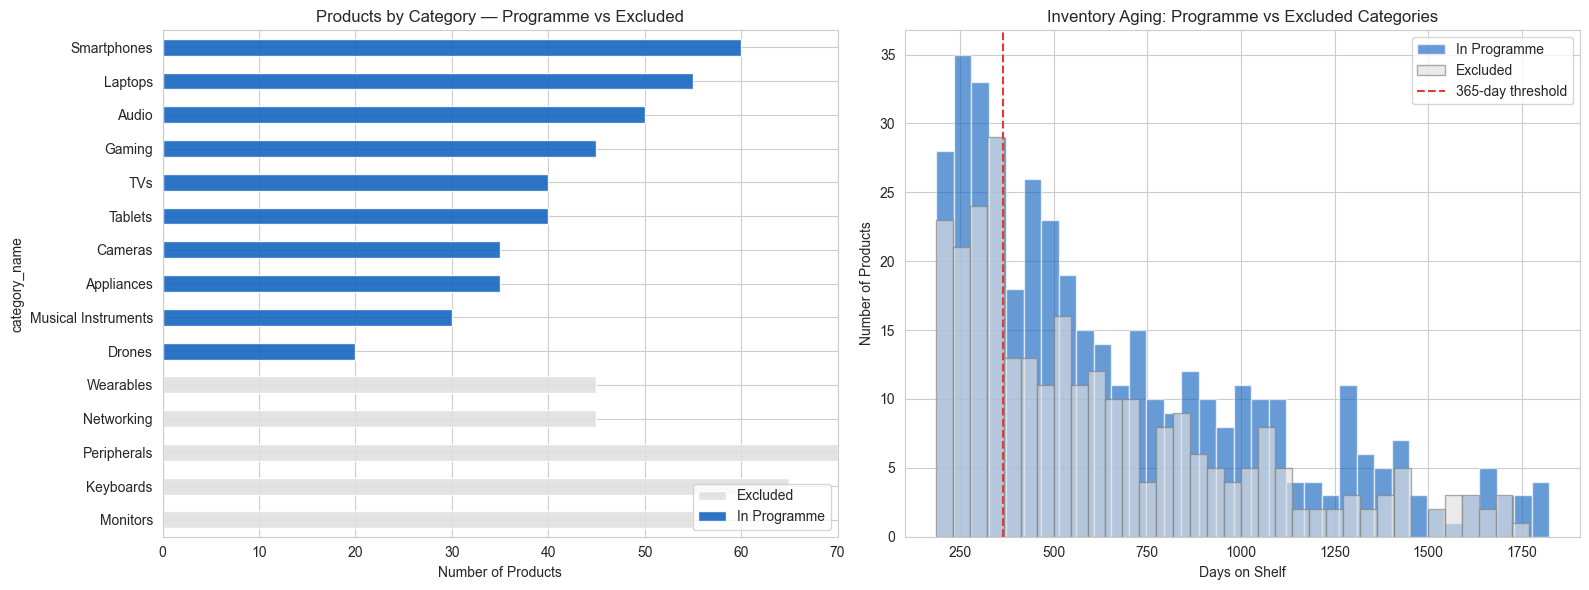


Rental-eligible (365+ days, programme categories only):
  292 out of 410 programme products (71.2%)
  Win rate and ratio calculations are based on this subset only.


In [7]:
# ── Programme vs Non-Programme Category Analysis ──────────────────────────────

# Load rental_programme flag from categories
prog_cats    = categories[categories["rental_programme"] == True]["category_name"].tolist()
nonprog_cats = categories[categories["rental_programme"] == False]["category_name"].tolist()

# Exclusion reasoning per category
exclusion_reasons = {
    "Wearables":   "Personal/hygiene items — smartwatches and fitness trackers have direct skin contact and strong personal attachment",
    "Keyboards":   "Commodity peripherals (€20–€250); customers buy rather than rent at these price points",
    "Monitors":    "B2B-only use case — temporary office setups are IT procurement, not consumer retail rental",
    "Networking":  "Routers and switches — not a consumer rental behaviour; typically purchased or provided by ISP",
    "Peripherals": "Mice, cables, adapters (€10–€150); too low-value to justify rental programme overhead",
}

print("=" * 65)
print("RENTAL PROGRAMME SCOPE")
print("=" * 65)
print(f"\n✅ IN PROGRAMME ({len(prog_cats)} categories):")
for c in sorted(prog_cats):
    print(f"   • {c}")

print(f"\n❌ EXCLUDED ({len(nonprog_cats)} categories):")
for c in sorted(nonprog_cats):
    reason = exclusion_reasons.get(c, "Not a natural rental behaviour at this price point")
    print(f"   • {c:<20} → {reason}")

# ── Product count split ───────────────────────────────────────────────────────
products_with_prog = products.merge(categories[["category_id", "rental_programme", "category_name"]], on="category_id")
prog_count    = products_with_prog[products_with_prog["rental_programme"] == True].shape[0]
nonprog_count = products_with_prog[products_with_prog["rental_programme"] == False].shape[0]

print(f"\n{'─' * 65}")
print(f"Products in programme:     {prog_count:>4} ({prog_count/len(products)*100:.1f}%)")
print(f"Products excluded:         {nonprog_count:>4} ({nonprog_count/len(products)*100:.1f}%)")
print(f"Total products:            {len(products):>4}")

# ── Chart: days on shelf split by programme status ───────────────────────────
products_copy2 = products_with_prog.copy()
products_copy2["listed_date"] = pd.to_datetime(products_copy2["listed_date"])
products_copy2["days_on_shelf"] = (pd.Timestamp("2024-12-31") - products_copy2["listed_date"]).dt.days

in_prog  = products_copy2[products_copy2["rental_programme"] == True]
out_prog = products_copy2[products_copy2["rental_programme"] == False]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: stacked bar of product counts by category, coloured by programme status
cat_counts = products_copy2.groupby(["category_name", "rental_programme"]).size().unstack(fill_value=0)
cat_counts.columns = ["Excluded", "In Programme"]
cat_counts = cat_counts.sort_values("In Programme", ascending=True)
cat_counts.plot(
    kind="barh", stacked=True, ax=axes[0],
    color=["#E0E0E0", "#1565C0"], alpha=0.9, edgecolor="white"
)
axes[0].set_title("Products by Category — Programme vs Excluded", fontsize=12)
axes[0].set_xlabel("Number of Products")
axes[0].legend(loc="lower right")

# Right: inventory aging histogram — programme vs excluded overlay
axes[1].hist(in_prog["days_on_shelf"],  bins=35, alpha=0.65, color="#1565C0", label="In Programme",  edgecolor="white")
axes[1].hist(out_prog["days_on_shelf"], bins=35, alpha=0.65, color="#E0E0E0", label="Excluded",       edgecolor="grey")
axes[1].axvline(x=365, color="#E53935", linestyle="--", linewidth=1.5, label="365-day threshold")
axes[1].set_title("Inventory Aging: Programme vs Excluded Categories", fontsize=12)
axes[1].set_xlabel("Days on Shelf")
axes[1].set_ylabel("Number of Products")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/programme_vs_excluded.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Eligible breakdown: programme only ───────────────────────────────────────
eligible_prog = in_prog[in_prog["days_on_shelf"] >= 365]
print(f"\nRental-eligible (365+ days, programme categories only):")
print(f"  {len(eligible_prog):,} out of {prog_count:,} programme products ({len(eligible_prog)/prog_count*100:.1f}%)")
print(f"  Win rate and ratio calculations are based on this subset only.")


## 5 · Price Depreciation Over Time

<module 'matplotlib.pyplot' from 'c:\\Users\\Beatriz Fernandes\\Desktop\\IronHack\\Week by Week\\W8\\Final Project\\finalproject\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

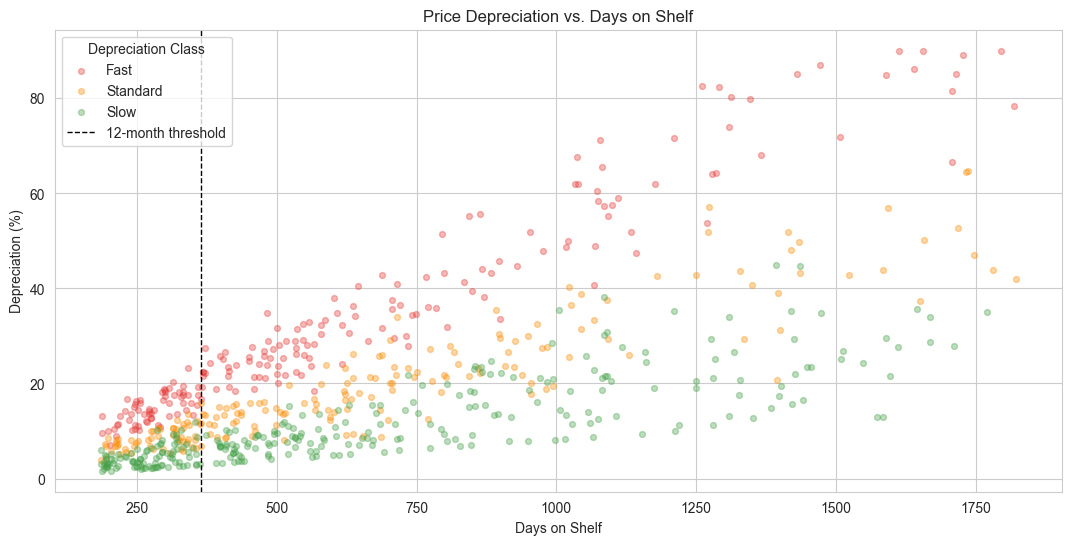

In [8]:
# How much value have products lost over time, and does it vary by depreciation class?
# depreciation_class (fast/standard/slow) is set per category in our data model
products_copy["depreciation_pct"] = (
    (products_copy["original_retail_price"] - products_copy["current_depreciated_value"])
    / products_copy["original_retail_price"] * 100
)

# Add depreciation class from categories
dep_class = products_copy.merge(
    categories[["category_id", "depreciation_class"]], 
    on="category_id"
)

fig, ax = plt.subplots(figsize=(13, 6))

colors = {"fast": "#E53935", "standard": "#FB8C00", "slow": "#43A047"}
for dep, color in colors.items():
    subset = dep_class[dep_class["depreciation_class"] == dep]
    ax.scatter(subset["days_on_shelf"], subset["depreciation_pct"],
               alpha=0.35, s=18, color=color, label=dep.capitalize())

ax.axvline(x=365, color="black", linestyle="--", linewidth=1, label="12-month threshold")
ax.set_title("Price Depreciation vs. Days on Shelf")
ax.set_xlabel("Days on Shelf")
ax.set_ylabel("Depreciation (%)")
ax.legend(title="Depreciation Class")

plt


## 6 · Rental Win Rate — First Look at the Hypothesis
For each product, we compare total rental revenue earned vs. what a graduated markdown would have made.
A "win" means rental came out ahead. This is the core question of the whole project.

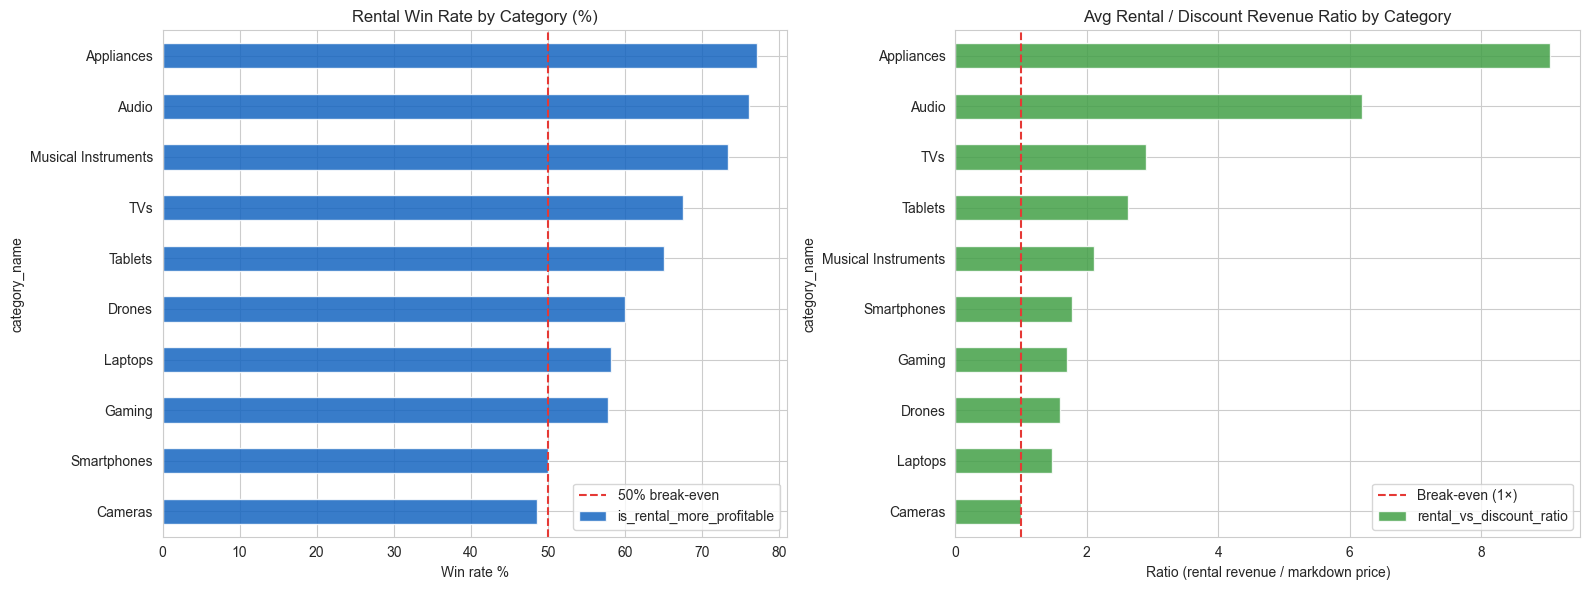

Overall rental win rate: 62.7%
Overall avg ratio:       3.03×
→ Full analysis in 03_ab_testing.ipynb


In [9]:
# Does rental beat a graduated markdown? And by how much?
win_by_cat = comparison.merge(
    products[["product_id", "category_id"]], on="product_id"
).merge(
    categories[["category_id", "category_name"]], on="category_id"
)

win_rate = win_by_cat.groupby("category_name")["is_rental_more_profitable"].mean().sort_values() * 100
avg_ratio = win_by_cat.groupby("category_name")["rental_vs_discount_ratio"].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

win_rate.plot(kind="barh", ax=axes[0], color="#1565C0", alpha=0.85)
axes[0].axvline(x=50, color="#E53935", linestyle="--", linewidth=1.5, label="50% break-even")
axes[0].set_title("Rental Win Rate by Category (%)")
axes[0].set_xlabel("Win rate %")
axes[0].legend()

avg_ratio.sort_values().plot(kind="barh", ax=axes[1], color="#43A047", alpha=0.85)
axes[1].axvline(x=1, color="#E53935", linestyle="--", linewidth=1.5, label="Break-even (1×)")
axes[1].set_title("Avg Rental / Discount Revenue Ratio by Category")
axes[1].set_xlabel("Ratio (rental revenue / markdown price)")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/win_rate_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

overall_win = comparison["is_rental_more_profitable"].mean() * 100
overall_ratio = comparison["rental_vs_discount_ratio"].mean()
print(f"Overall rental win rate: {overall_win:.1f}%")
print(f"Overall avg ratio:       {overall_ratio:.2f}×")
print("→ Full analysis in 03_ab_testing.ipynb")


## 7 · Repeat Rental Rate — Who Comes Back?
A one-time renter and a loyal renter look the same in a segment label.
Here we look at *how many times* each customer actually rented, and what
share of revenue comes from repeat customers vs. one-timers.

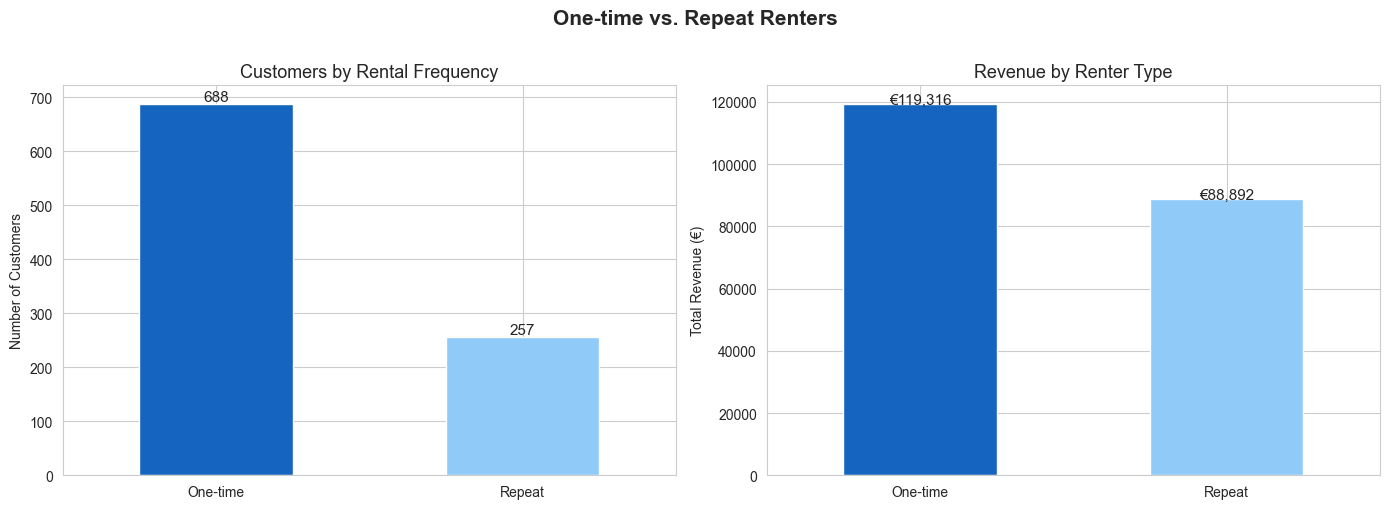

Repeat renters: 27.2% of active customers
Revenue from repeat renters: 42.7% of total


In [10]:
# How many customers rented more than once, and how much do they contribute?

# Count rentals per customer (only customers who rented at least once)
rental_counts = rentals.groupby("customer_id")["rental_id"].count().reset_index()
rental_counts.columns = ["customer_id", "rental_count"]

# Label them: one-time vs. repeat
rental_counts["renter_type"] = rental_counts["rental_count"].apply(
    lambda x: "One-time" if x == 1 else "Repeat"
)

# How many of each?
type_counts = rental_counts["renter_type"].value_counts()

# Join back to rentals to get revenue by renter type
rental_counts_rev = rental_counts.merge(
    rentals.groupby("customer_id")["total_rental_revenue"].sum().reset_index(),
    on="customer_id"
)
rev_by_type = rental_counts_rev.groupby("renter_type")["total_rental_revenue"].sum()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: number of customers
type_counts.plot(kind="bar", ax=axes[0], color=["#1565C0", "#90CAF9"], edgecolor="white")
axes[0].set_title("Customers by Rental Frequency", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                 f"{int(bar.get_height())}", ha="center", fontsize=11)

# Right: revenue contribution
rev_by_type.plot(kind="bar", ax=axes[1], color=["#1565C0", "#90CAF9"], edgecolor="white")
axes[1].set_title("Revenue by Renter Type", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("Total Revenue (€)")
axes[1].tick_params(axis="x", rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"€{bar.get_height():,.0f}", ha="center", fontsize=11)

plt.suptitle("One-time vs. Repeat Renters", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/repeat_rental_rate.png", dpi=150, bbox_inches="tight")
plt.show()

# Print a summary
repeat_pct = (type_counts.get("Repeat", 0) / type_counts.sum()) * 100
rev_repeat_pct = (rev_by_type.get("Repeat", 0) / rev_by_type.sum()) * 100
print(f"Repeat renters: {repeat_pct:.1f}% of active customers")
print(f"Revenue from repeat renters: {rev_repeat_pct:.1f}% of total")

## 8 · Top Spenders — The Customers Carrying the Program
We already know repeat renters drive 50% of revenue with 30% of customers.
Now let's find out *who* the heavy hitters actually are — the top 10 customers
by total spend, and whether high spenders tend to rent for longer or just more often.

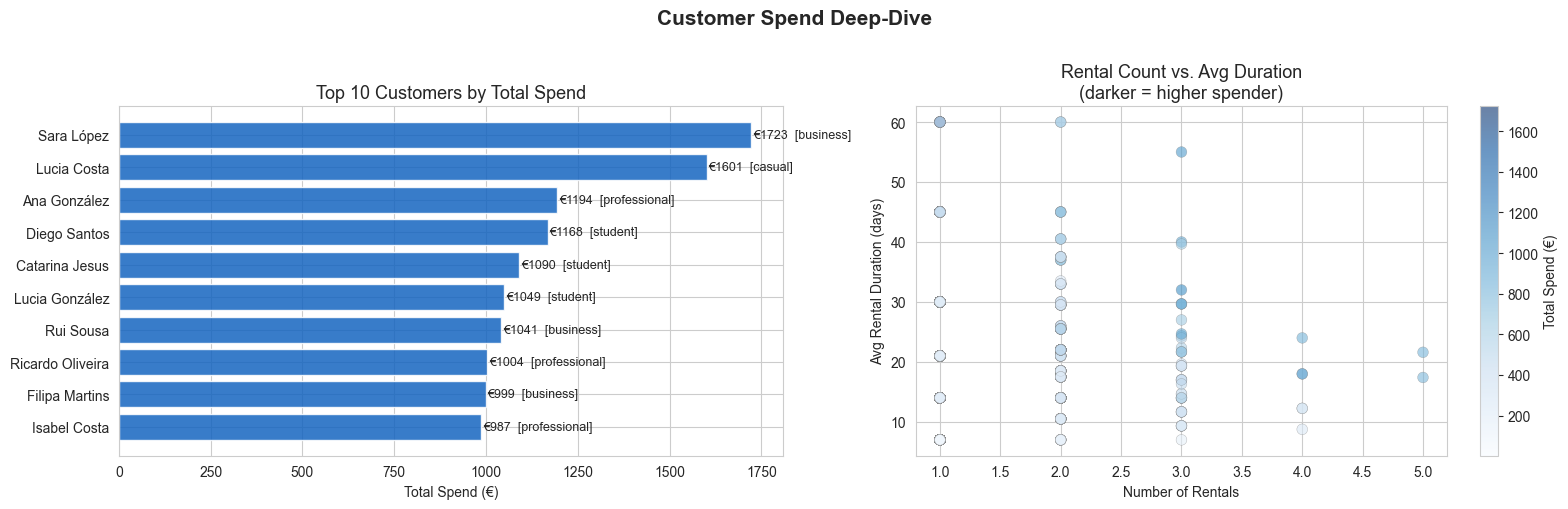

Top 10 spenders:
   customer_name customer_segment  spent_€  total_rentals  avg_days
      Sara López         business  1722.77              1      45.0
     Lucia Costa           casual  1601.30              1      60.0
    Ana González     professional  1194.02              1      45.0
    Diego Santos          student  1167.72              1      45.0
  Catarina Jesus          student  1090.36              3      32.0
  Lucia González          student  1048.90              1      45.0
       Rui Sousa         business  1041.17              4      18.0
Ricardo Oliveira     professional  1003.59              3      55.0
  Filipa Martins         business   998.93              2      22.0
    Isabel Costa     professional   987.14              1      60.0


In [11]:
# Who are the top spenders, and how do they behave?

# Build a per-customer summary
customer_summary = rentals.groupby("customer_id").agg(
    total_spent=("total_rental_revenue", "sum"),
    total_rentals=("rental_id", "count"),
    avg_duration=("rental_duration_days", "mean")
).reset_index()

# Join in customer name and segment
customer_summary = customer_summary.merge(
    customers[["customer_id", "first_name", "last_name", "customer_segment"]],
    on="customer_id"
)

# Combine into a single display name
customer_summary["customer_name"] = customer_summary["first_name"] + " " + customer_summary["last_name"]

# Top 10 by total spend
top10 = customer_summary.nlargest(10, "total_spent").reset_index(drop=True)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: top 10 bar chart
axes[0].barh(top10["customer_name"], top10["total_spent"], color="#1565C0", alpha=0.85)
axes[0].set_title("Top 10 Customers by Total Spend", fontsize=13)
axes[0].set_xlabel("Total Spend (€)")
axes[0].invert_yaxis()  # highest at the top
for i, (val, seg) in enumerate(zip(top10["total_spent"], top10["customer_segment"])):
    axes[0].text(val + 5, i, f"€{val:.0f}  [{seg}]", va="center", fontsize=9)

# Right: scatter — number of rentals vs. avg duration, sized by total spend
scatter = axes[1].scatter(
    customer_summary["total_rentals"],
    customer_summary["avg_duration"],
    c=customer_summary["total_spent"],
    cmap="Blues",
    alpha=0.6,
    edgecolors="grey",
    linewidth=0.3,
    s=60
)
plt.colorbar(scatter, ax=axes[1], label="Total Spend (€)")
axes[1].set_title("Rental Count vs. Avg Duration\n(darker = higher spender)", fontsize=13)
axes[1].set_xlabel("Number of Rentals")
axes[1].set_ylabel("Avg Rental Duration (days)")

plt.suptitle("Customer Spend Deep-Dive", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/top_spenders.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary
print("Top 10 spenders:")
print(top10[["customer_name", "customer_segment", "total_spent", "total_rentals", "avg_duration"]]
      .rename(columns={"total_spent": "spent_€", "avg_duration": "avg_days"})
      .to_string(index=False))

## 9 · Rental Duration — How Long Do People Actually Keep Things?
Duration drives revenue just as much as frequency.
Here we look at the spread of rental lengths across the whole programme,
and whether different categories tend toward short or long rentals.

Overall rental duration stats (days):
count    1264.0
mean       20.8
std        13.0
min         7.0
25%        14.0
50%        14.0
75%        30.0
max        60.0
Name: rental_duration_days, dtype: float64


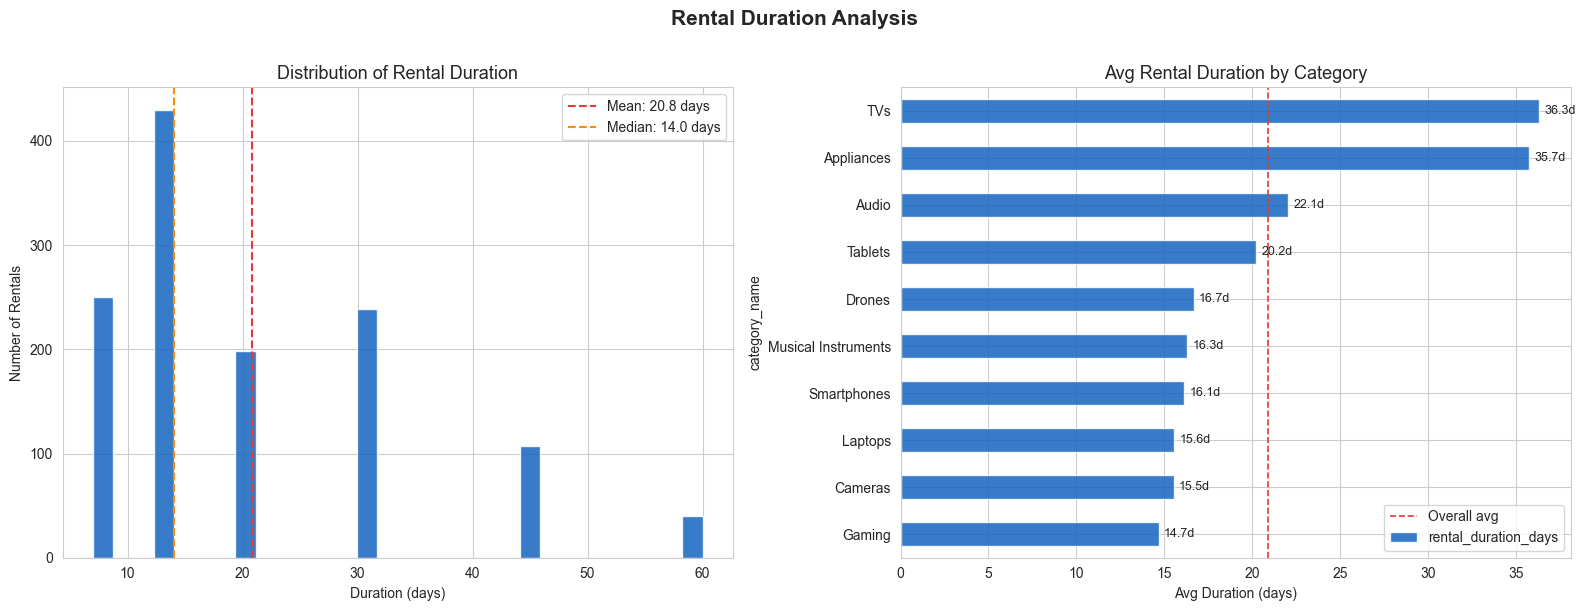

In [12]:
# How long do rentals last, and does it vary by category?

# Add category name to rentals
rental_duration = rentals.merge(
    products[["product_id", "category_id"]], on="product_id"
).merge(
    categories[["category_id", "category_name"]], on="category_id"
)

# Overall duration stats
print("Overall rental duration stats (days):")
print(rental_duration["rental_duration_days"].describe().round(1))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: histogram of all rental durations
axes[0].hist(rental_duration["rental_duration_days"], bins=30,
             color="#1565C0", alpha=0.85, edgecolor="white")
axes[0].set_title("Distribution of Rental Duration", fontsize=13)
axes[0].set_xlabel("Duration (days)")
axes[0].set_ylabel("Number of Rentals")
axes[0].axvline(rental_duration["rental_duration_days"].mean(), color="#E53935",
                linestyle="--", linewidth=1.5, label=f"Mean: {rental_duration['rental_duration_days'].mean():.1f} days")
axes[0].axvline(rental_duration["rental_duration_days"].median(), color="#FB8C00",
                linestyle="--", linewidth=1.5, label=f"Median: {rental_duration['rental_duration_days'].median():.1f} days")
axes[0].legend()

# Right: avg duration by category (horizontal bar)
avg_duration = rental_duration.groupby("category_name")["rental_duration_days"].mean().sort_values()
avg_duration.plot(kind="barh", ax=axes[1], color="#1565C0", alpha=0.85)
axes[1].set_title("Avg Rental Duration by Category", fontsize=13)
axes[1].set_xlabel("Avg Duration (days)")
axes[1].axvline(avg_duration.mean(), color="#E53935", linestyle="--", linewidth=1.2, label="Overall avg")
axes[1].legend()

for bar, val in zip(axes[1].patches, avg_duration):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f"{val:.1f}d", va="center", fontsize=9)

plt.suptitle("Rental Duration Analysis", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/rental_duration.png", dpi=150, bbox_inches="tight")
plt.show()

## 10 · Price Tier vs. Revenue — Do Expensive Products Earn More?
A high retail price doesn't automatically mean high rental revenue.
Here we bucket products into price tiers and compare how much rental
revenue each tier actually generates — in total and on average per rental.

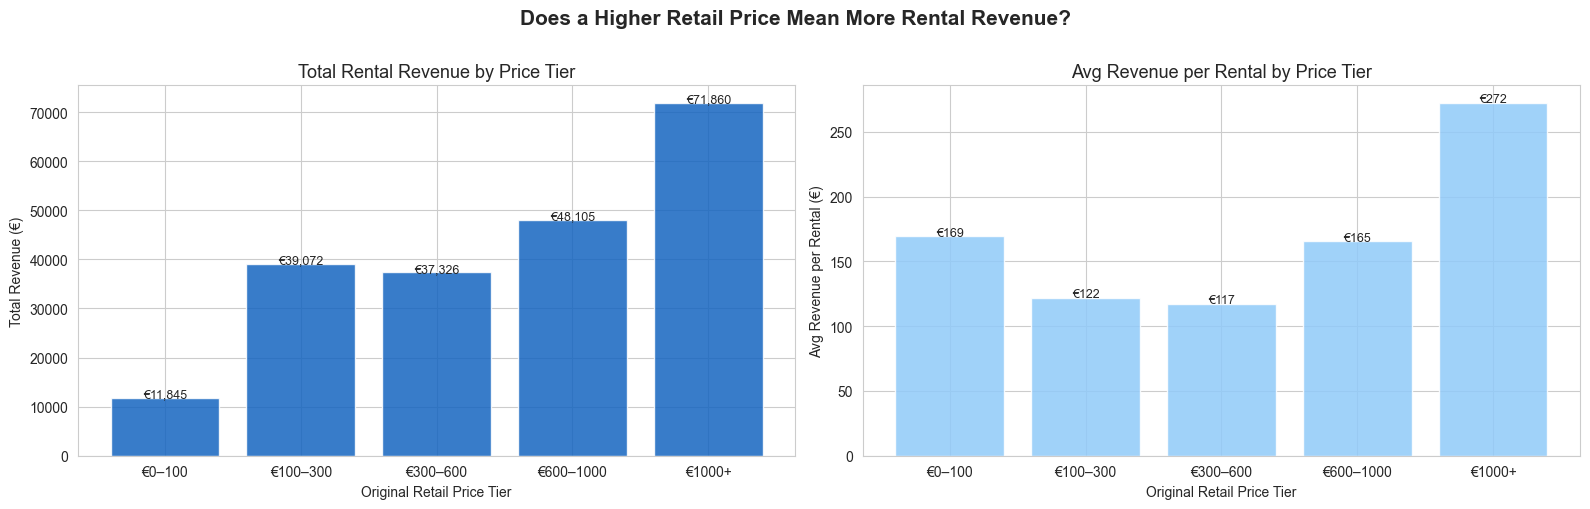

Summary by price tier:
price_tier  total_revenue  avg_revenue_per_rental  rental_count
    €0–100       11844.60              169.208571            70
  €100–300       39072.39              121.720841           321
  €300–600       37325.83              117.376824           318
 €600–1000       48105.01              165.309313           291
    €1000+       71860.30              272.198106           264


In [13]:
# Do higher-priced products generate more rental revenue?

# Step 1: bucket products into price tiers based on retail price
price_bins   = [0, 100, 300, 600, 1000, 9999]
price_labels = ["€0–100", "€100–300", "€300–600", "€600–1000", "€1000+"]

products_copy["price_tier"] = pd.cut(
    products_copy["original_retail_price"],
    bins=price_bins,
    labels=price_labels
)

# Step 2: join price tier onto rentals
rental_price = rentals.merge(
    products_copy[["product_id", "price_tier", "original_retail_price"]],
    on="product_id"
)

# Step 3: aggregate by tier
tier_summary = rental_price.groupby("price_tier", observed=True).agg(
    total_revenue=("total_rental_revenue", "sum"),
    avg_revenue_per_rental=("total_rental_revenue", "mean"),
    rental_count=("rental_id", "count")
).reset_index()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: total revenue by tier
axes[0].bar(tier_summary["price_tier"], tier_summary["total_revenue"],
            color="#1565C0", alpha=0.85, edgecolor="white")
axes[0].set_title("Total Rental Revenue by Price Tier", fontsize=13)
axes[0].set_xlabel("Original Retail Price Tier")
axes[0].set_ylabel("Total Revenue (€)")
for bar, val in zip(axes[0].patches, tier_summary["total_revenue"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
                 f"€{val:,.0f}", ha="center", fontsize=9)

# Right: avg revenue per rental by tier
axes[1].bar(tier_summary["price_tier"], tier_summary["avg_revenue_per_rental"],
            color="#90CAF9", alpha=0.85, edgecolor="white")
axes[1].set_title("Avg Revenue per Rental by Price Tier", fontsize=13)
axes[1].set_xlabel("Original Retail Price Tier")
axes[1].set_ylabel("Avg Revenue per Rental (€)")
for bar, val in zip(axes[1].patches, tier_summary["avg_revenue_per_rental"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"€{val:.0f}", ha="center", fontsize=9)

plt.suptitle("Does a Higher Retail Price Mean More Rental Revenue?", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/price_tier_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
print("Summary by price tier:")
print(tier_summary.to_string(index=False))

## 11 · Day-of-Week Patterns — When Do People Start Rentals?
Knowing *when* customers initiate rentals helps with staffing, marketing,
and stock availability planning. Here we look at which days of the week
see the most rental activity, and whether that pattern holds across categories.

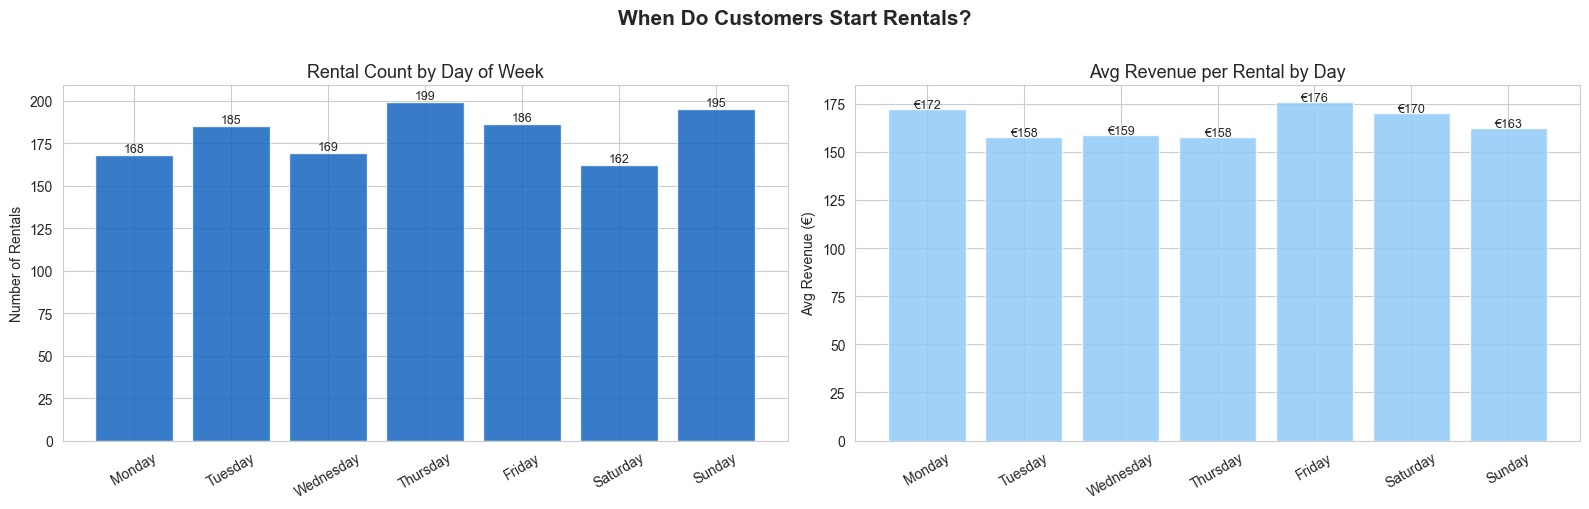

Rentals by day of week:
day_of_week  rental_count  avg_revenue
     Monday           168   172.123810
    Tuesday           185   157.594432
  Wednesday           169   158.645385
   Thursday           199   157.620251
     Friday           186   175.715269
   Saturday           162   170.215432
     Sunday           195   162.568821

Busiest day:  Thursday
Quietest day: Saturday


In [14]:
# Which days of the week do most rentals start?

# Extract day of week from rental start date
rentals["day_of_week"] = rentals["rental_start_date"].dt.day_name()

# Define correct order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Count rentals and revenue by day
day_summary = rentals.groupby("day_of_week").agg(
    rental_count=("rental_id", "count"),
    avg_revenue=("total_rental_revenue", "mean")
).reindex(day_order).reset_index()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: rental count by day
axes[0].bar(day_summary["day_of_week"], day_summary["rental_count"],
            color="#1565C0", alpha=0.85, edgecolor="white")
axes[0].set_title("Rental Count by Day of Week", fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Rentals")
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(axes[0].patches, day_summary["rental_count"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 str(int(val)), ha="center", fontsize=9)

# Right: avg revenue per rental by day
axes[1].bar(day_summary["day_of_week"], day_summary["avg_revenue"],
            color="#90CAF9", alpha=0.85, edgecolor="white")
axes[1].set_title("Avg Revenue per Rental by Day", fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("Avg Revenue (€)")
axes[1].tick_params(axis="x", rotation=30)
for bar, val in zip(axes[1].patches, day_summary["avg_revenue"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f"€{val:.0f}", ha="center", fontsize=9)

plt.suptitle("When Do Customers Start Rentals?", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/day_of_week_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary
print("Rentals by day of week:")
print(day_summary.to_string(index=False))
print(f"\nBusiest day:  {day_summary.loc[day_summary['rental_count'].idxmax(), 'day_of_week']}")
print(f"Quietest day: {day_summary.loc[day_summary['rental_count'].idxmin(), 'day_of_week']}")

> ⚠️ **Note:** The flat distribution across all seven days is a direct result of
> artificially generated data — rentals were assigned random start dates with no
> real-world behavioural logic applied. In a real retail rental system you would
> expect clear peaks (e.g. Friday pick-ups, weekend returns). This analysis is
> included to show *how* the calculation would work, not to draw conclusions from
> the numbers themselves.

## 12 · Rental Competitiveness by Discount Depth
Does the rental advantage hold even at deep discounts?
This is an exploratory breakdown — not a formal test. We split products by discount tier
and check whether the rental ratio and win rate hold up across the full range.

discount_tier  n_products  avg_ratio  pct_rental_wins
      25% off          26   0.101750              3.8
      35% off          64   1.464666             37.5
      45% off          79   0.858939             22.8
      55% off          48   3.038556             70.8
      65% off          74   5.515065             94.6
      70% off          17   2.390624             82.4
      72% off          52   5.732846             90.4
      75% off          50   3.685312             98.0


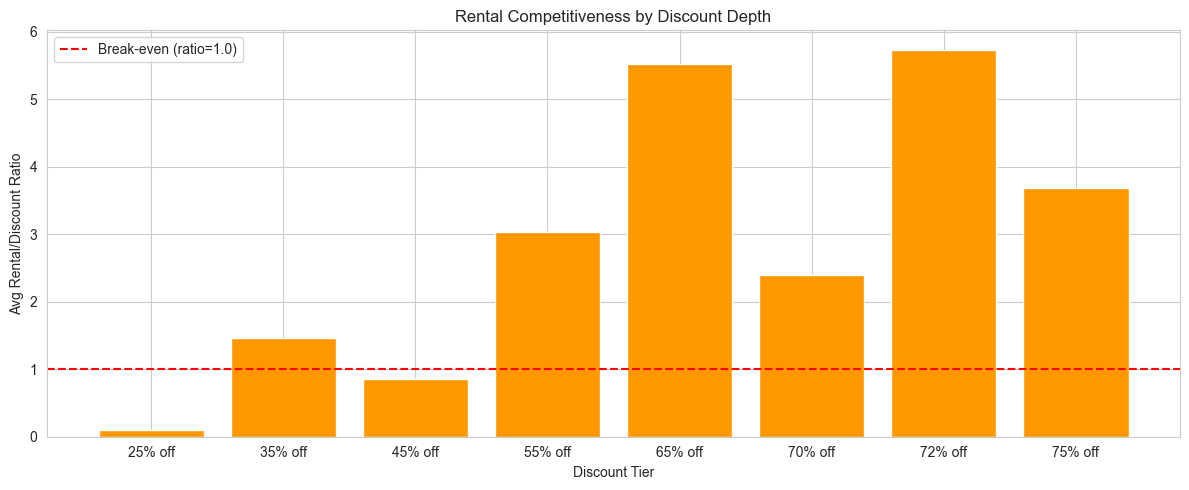

In [15]:
# Does rental win rate change depending on how deep the markdown discount is?
# Deeper discounts should make rental less competitive — let's verify
comparison = pd.read_csv(f"{DATA_DIR}/rental_revenue_vs_discount.csv")

comparison["discount_tier"] = (comparison["discount_pct"] * 100).astype(int).astype(str) + "% off"

tier_analysis = comparison.groupby("discount_tier").agg(
    n_products=("product_id", "count"),
    avg_ratio=("rental_vs_discount_ratio", "mean"),
    pct_rental_wins=("is_rental_more_profitable", "mean")
).reset_index()
tier_analysis["pct_rental_wins"] = (tier_analysis["pct_rental_wins"] * 100).round(1)

# Sort numerically, not alphabetically — "30% off" should not come before "25% off"
tier_analysis = tier_analysis.sort_values(
    "discount_tier",
    key=lambda x: x.str.replace("% off", "").astype(int)
)

print(tier_analysis.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(tier_analysis["discount_tier"], tier_analysis["avg_ratio"], color="#FF9800", edgecolor="white")
ax.axhline(y=1.0, color="red", linestyle="--", linewidth=1.5, label="Break-even (ratio=1.0)")
ax.set_xlabel("Discount Tier")
ax.set_ylabel("Avg Rental/Discount Ratio")
ax.set_title("Rental Competitiveness by Discount Depth")
ax.legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/profitability_by_discount.png", dpi=150, bbox_inches="tight")
plt.show()

---
## ✅ EDA Deliverables

| # | Chart | File | Key Finding |
|---|---|---|---|
| 1 | Revenue distribution by category | `revenue_by_category.png` | Which categories generate the most rental revenue |
| 2 | Monthly rental timeline / seasonality | `seasonal_patterns.png` | How rental activity and revenue evolved month by month |
| 3 | Customer behaviour by segment | `customer_segments.png` | How rentals and spending break down by segment |
| 4 | Inventory aging — days on shelf | `inventory_aging.png` | How long products have been sitting unsold |
| 4B | Programme vs non-programme split | `programme_vs_excluded.png` | Which categories qualify for rental and why |
| 5 | Price depreciation scatter | `price_depreciation.png` | Value loss over time by depreciation class |
| 6 | Win rate & ratio preview by category | `win_rate_by_category.png` | Rental vs. markdown — first look at the core hypothesis |
| 7 | One-time vs. repeat renters | `repeat_rental_rate.png` | 30% of customers are repeat renters but drive 50% of revenue |
| 8 | Customer spend deep-dive | `top_spenders.png` | Top 10 spenders — duration matters as much as frequency |
| 9 | Rental duration analysis | `rental_duration.png` | Clear split: bulky items kept 35–38 days, gadgets 15–23 days |
| 10 | Price tier vs. revenue | `price_tier_vs_revenue.png` | Mid-range (€300–600) drives total revenue; €1000+ wins per transaction |
| 11 | Day-of-week patterns | `day_of_week_patterns.png` | ⚠️ Artificial data — included as methodology only |
| 12 | Rental competitiveness by discount depth | `profitability_by_discount.png` | Rental advantage holds across all discount tiers |

**→ Proceed to `03_ab_testing.ipynb`**